# Sequential recommendations

## Introduction

In the previous chapter, the two towers learned a vector for every user and every film. But the user tower read the likes as a **bag**: all mixed together. The horror film you watched yesterday counted as much as the comedy you watched two years ago.

Yet the order says a lot. Think about how you watch films: after a great horror film, you probably want another one. After a Disney film with the kids, the next one is likely a Disney film too.

That is the idea of **sequential recommendation**: *read the history as a trail, and guess what comes next.*

![The last five films our horror fan liked, in order: A Nightmare on Elm Street, The Body Snatcher, The Omen, Carrie, Bram Stoker's Dracula. What comes next?](images/history_trail.svg)

## Example scenario

Same data, same user, same test as in the previous chapters, so we can compare the scores. First, the films and the ratings:

In [1]:
from recommendationsystems.movielens import load_movies, load_ratings

_, titles, _ = load_movies()  # no genres this time either
ratings = load_ratings()
print(ratings[:5])

[[259 254   4]
 [259 285   4]
 [259 297   4]
 [259 184   4]
 [259 172   4]]


As a reminder: we **hide the last 10 ratings** of each user. The recommender only sees the rest, the **history**, and suggests 10 films. If at least one of them was liked later (rated 4 or 5), it is a **hit**! We follow our horror fan, user 366.

In [2]:
import numpy as np
from recommendationsystems.movielens import MovieId, UserId

fan = 366
history = {}  # key: user, value: array of (film, rating) the recommender can see
liked_later = {}  # key: user, value: set of hidden films the user liked
for user in np.unique(ratings[:, 0]):
    user_ratings = ratings[ratings[:, 0] == user]
    history[user] = user_ratings[:-10, 1:]
    liked_later[user] = {movie for movie, rating in user_ratings[-10:, 1:] if rating >= 4}

def liked(user: UserId) -> np.ndarray:
    return history[user][history[user][:, 1] >= 4, 0]

As before, a recommender gives **a score to every film**, and we keep the 10 films with the best score, skipping the films the user has already seen. The **hit rate** is the share of users for whom we got at least one hit.

In [3]:
from collections.abc import Callable

def top_10(scores: np.ndarray, user: UserId) -> list[MovieId]:
    """Return the 10 best-scored films that the user has not seen yet."""
    seen = set(history[user][:, 0])
    best_first = np.argsort(-scores, kind="stable")  # all films, best score first
    return [int(movie) for movie in best_first if movie not in seen][:10]

test_users = [user for user in history if liked_later[user] and len(liked(user))]

def evaluate(reco: Callable[[UserId], list[MovieId]]) -> float:
    hits = [bool(set(reco(user)) & liked_later[user]) for user in test_users]
    return sum(hits) / len(hits)

Our two reference points, random films and popular films:

In [4]:
rng = np.random.default_rng(21)

def random_reco(user: UserId) -> list[MovieId]:
    return top_10(rng.random(len(titles)), user)

likes = np.bincount(np.concatenate([liked(user) for user in history]), minlength=len(titles))

def popular_reco(user: UserId) -> list[MovieId]:
    return top_10(likes, user)

print(f"Random: {evaluate(random_reco):.3f}")
print(f"Popular: {evaluate(popular_reco):.3f}")

Random: 0.034
Popular: 0.346


And the best recommender so far, the 40 nearest neighbors of chapter 3, reached 0.518. That is the score to beat.

One last thing: the ratings are sorted by time, so `liked(user)` is already a trail, oldest first. Here are the last films our fan liked:

In [5]:
for movie in liked(fan)[-5:]:
    print(titles[movie])

Nightmare on Elm Street, A (1984)
Body Snatcher, The (1945)
Omen, The (1976)
Carrie (1976)
Bram Stoker's Dracula (1992)


## What comes next?

### a. Let's count the pairs

Let's start simple. When people liked a film, what did they like **right after**? We go through every trail, and count every pair of films liked one after the other:

![Three users liked Carrie. Right after it, two of them liked The Shining and one liked The Omen.](images/what_comes_next.svg)

The counts fit in a table with one row and one column per film:

In [6]:
n_films = len(titles)
after = np.zeros((n_films, n_films))  # after[a, b]: how many times b was liked right after a
for user in history:
    trail = liked(user)
    for film, next_film in zip(trail[:-1], trail[1:]):
        after[film, next_film] += 1

What did people like right after Carrie?

In [7]:
carrie = titles.index("Carrie (1976)")
for movie in np.argsort(-after[carrie], kind="stable")[:3]:
    print(f"{titles[movie]}: {after[carrie, movie]:.0f} times")

Nightmare on Elm Street, A (1984): 4 times
Twelve Monkeys (1995): 2 times
Silence of the Lambs, The (1991): 2 times


### b. Let's recommend from the last film

To recommend, we look at the last film the user liked, and read its row: the films that usually come next.

In [8]:
def last_film_reco(user: UserId) -> list[MovieId]:
    return top_10(after[liked(user)[-1]], user)

for movie in last_film_reco(fan):
    print(titles[movie])

Tales From the Crypt Presents: Demon Knight (1995)
Batman Forever (1995)
I.Q. (1994)
Natural Born Killers (1994)
Firm, The (1993)
Blade Runner (1982)
Lawnmower Man, The (1992)
Basic Instinct (1992)
Shining, The (1980)
Die Hard 2 (1990)


### c. How does this recommender perform?

In [9]:
print(f"Last film: {evaluate(last_film_reco):.3f}")

Last film: 0.406


Better than popular films, with a very simple table! But far from the nearest neighbors.

A single film is a thin clue. Our fan's last like is Dracula, and the list above mixes Batman Forever with Die Hard 2: whatever people happened to like after Dracula. One odd film at the end of a trail, and the whole list goes astray.

## The last few films

### a. Let's make them vote

Instead of the last film only, let's use the last 5. Each of them votes for the films that usually come after it, and we add up the votes:

In [10]:
def last_films_reco(user: UserId, k: int = 5) -> list[MovieId]:
    return top_10(after[liked(user)[-k:]].sum(axis=0), user)

for movie in last_films_reco(fan):
    print(titles[movie])

Shining, The (1980)
Natural Born Killers (1994)
Bananas (1971)
Interview with the Vampire (1994)
Alien 3 (1992)
GoldenEye (1995)
Ed Wood (1994)
I.Q. (1994)
Lion King, The (1994)
Lawnmower Man, The (1992)


The Shining comes first: one of the films our fan liked later. A hit!

### b. How does this recommender perform?

In [11]:
print(f"Last 5 films: {evaluate(last_films_reco):.3f}")

Last 5 films: 0.502


A big jump! Almost as good as the nearest neighbors.

But why 5? Let's try a few values, from the last film only to the whole history:

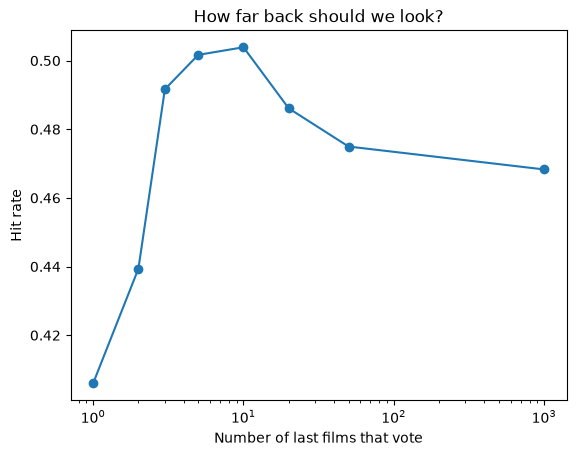

In [12]:
import matplotlib.pyplot as plt

film_counts = [1, 2, 3, 5, 10, 20, 50, 1000]
hit_rates = [evaluate(lambda user, k=k: last_films_reco(user, k)) for k in film_counts]

plt.plot(film_counts, hit_rates, marker="o")
plt.xscale("log")
plt.xlabel("Number of last films that vote")
plt.ylabel("Hit rate")
plt.title("How far back should we look?")
plt.show()

With too few films, one odd film decides everything. With the whole history, old films drown out the recent ones. The best is in between: **the recent films matter more**.

Still, we chose the rules by hand: the last 5 films, each worth one vote. Yet some films say more than others. Maybe your last film is a comedy you watched with friends, and the three horror films before it say much more about you. What if the model learned by itself how much each film counts?

## SASRec: let the model choose

### a. Attention in one picture

That is the idea of **SASRec**, for *Self-Attentive Sequential Recommendation* ([Kang and McAuley, 2018](https://arxiv.org/abs/1808.09781)).

Like in chapter 4, every film gets a vector. To guess what comes after Dracula, the model looks back at the films before it, and gives each of them a **weight**: how much it counts. Then it blends their vectors with these weights. This is called **attention**.

![Dracula looks back at the earlier films with learned weights: 0.10 for A Nightmare on Elm Street, 0.35 for The Body Snatcher, 0.20 for The Omen, 0.15 for Carrie, 0.20 for itself. The blend of their vectors is compared with every film.](images/attention.svg)

The blend is a vector too. As with the two towers, its dot product with the vector of each film gives the score of that film.

Two more details:
- a film at the end of the trail and the same film at the beginning should not count the same. So each **position** in the trail also gets a vector, added to the vector of the film,
- a film only looks **back**, never forward. It is the future: this is what we try to guess!

### b. Let's cut the trails

The model reads trails of 20 films. A shorter trail is filled at the start with an extra film number, `NO_FILM`, which means "nothing here":

In [13]:
LENGTH = 20
NO_FILM = n_films  # the films are numbered 0 to 1681, so 1682 is free

def pad(trail: np.ndarray, length: int = LENGTH) -> list[MovieId]:
    """Keep the last films of the trail, and fill the start with NO_FILM."""
    trail = [int(movie) for movie in trail[-length:]]
    return [NO_FILM] * (length - len(trail)) + trail

print(pad(liked(fan)[-3:]))

[1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 1682, 447, 446, 216]


To train, one trail gives many guesses at once. For the small trail `[A, B, C, D]`:

| What the model reads | What it should guess |
| --- | --- |
| `[A]` | `B` |
| `[A, B]` | `C` |
| `[A, B, C]` | `D` |

So we cut every history into pieces of 21 films: the model reads the first 20, and guesses the next film at every position. A long history gives several pieces:

In [14]:
import torch

pieces = []
for user in history:
    trail = liked(user)
    for end in range(len(trail), 1, -LENGTH):  # from the end, LENGTH films at a time
        pieces.append(pad(trail[:end], LENGTH + 1))
pieces = torch.tensor(pieces)

print(f"Pieces: {len(pieces)}")

Pieces: 2928


### c. Let's build the model

The vectors of the films are a table, exactly like the first towers of chapter 4: a film number picks one row. PyTorch calls it an `nn.Embedding`. Same thing for the positions.

The attention is given by PyTorch too: `nn.TransformerEncoderLayer`. It is the building block of the **Transformers**, the models behind ChatGPT. They guess the next word of a text; we guess the next film of a trail. After the attention, the block also passes each vector through a small neural network.

The `look_back_only` mask tells the attention which films each position may look at: itself and the films before it.

In [15]:
from torch import nn

class SASRec(nn.Module):
    def __init__(self, size: int = 64):
        super().__init__()
        self.films = nn.Embedding(n_films + 1, size, padding_idx=NO_FILM)  # + 1 for NO_FILM
        self.positions = nn.Embedding(LENGTH, size)
        self.attention = nn.TransformerEncoderLayer(size, nhead=2, dim_feedforward=size, dropout=0.2, batch_first=True)
        self.look_back_only = nn.Transformer.generate_square_subsequent_mask(LENGTH)

    def forward(self, trails: torch.Tensor) -> torch.Tensor:
        """Return, at every position, the score of every film to come next."""
        vectors = self.films(trails) + self.positions.weight
        vectors = self.attention(vectors, src_mask=self.look_back_only, is_causal=True)
        return vectors @ self.films.weight[:n_films].T  # dot product with every film

### d. Let's train it

Same loss as in chapter 4, the **cross-entropy**: at each position, among the 1,682 films, which one came next? We just ignore the positions where the answer is `NO_FILM`.

One trick: we only have 943 users, so the model could learn their trails by heart. The **weight decay** pulls the film vectors a little toward 0 at every step, so only the patterns shared by many users survive.

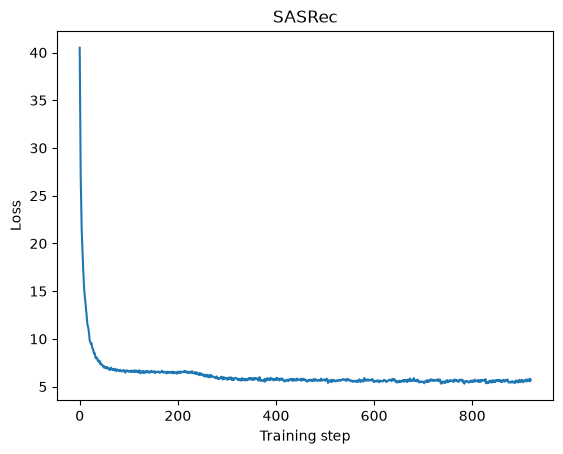

In [16]:
torch.manual_seed(21)
model = SASRec()
optimizer = torch.optim.AdamW([
    {"params": [model.films.weight, model.positions.weight], "weight_decay": 1.0},
    {"params": model.attention.parameters(), "weight_decay": 0.0},
], lr=0.01)

losses = []
model.train()
for _ in range(20):  # an epoch is one pass over all the pieces
    for batch in pieces[torch.randperm(len(pieces))].split(64):
        scores = model(batch[:, :-1])  # read films 1 to 20
        guesses = batch[:, 1:]  # guess films 2 to 21
        loss = nn.functional.cross_entropy(scores.reshape(-1, n_films), guesses.reshape(-1), ignore_index=NO_FILM)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
model.eval()

plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("SASRec")
plt.show()

As in chapter 4, the loss starts around $\log(1682) \approx 7.4$, a random guess, and goes down.

### e. Let's recommend

To recommend, we give the model the last 20 films of the user, and read the scores at the last position: the guess of what comes after the last film.

In [17]:
def next_scores(trail: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        return model(torch.tensor([pad(trail)]))[0, -1].numpy()

def sasrec_reco(user: UserId) -> list[MovieId]:
    return top_10(next_scores(liked(user)), user)

for movie in sasrec_reco(fan):
    print(titles[movie])

Natural Born Killers (1994)
Jaws 2 (1978)
Shining, The (1980)
Tales From the Crypt Presents: Demon Knight (1995)
Copycat (1995)
Blob, The (1958)
Serial Mom (1994)
Prophecy, The (1995)
Interview with the Vampire (1994)
Killing Zoe (1994)


### f. How does this recommender perform?

In [18]:
print(f"SASRec: {evaluate(sasrec_reco):.3f}")

SASRec: 0.525


Our best score so far, just above the 40 nearest neighbors (0.518)! And it only reads the last 20 films of a user, where the neighbors compared every user with every other user.

### g. What did it look at?

We can ask the attention how much the last position looks at each of the films before it:

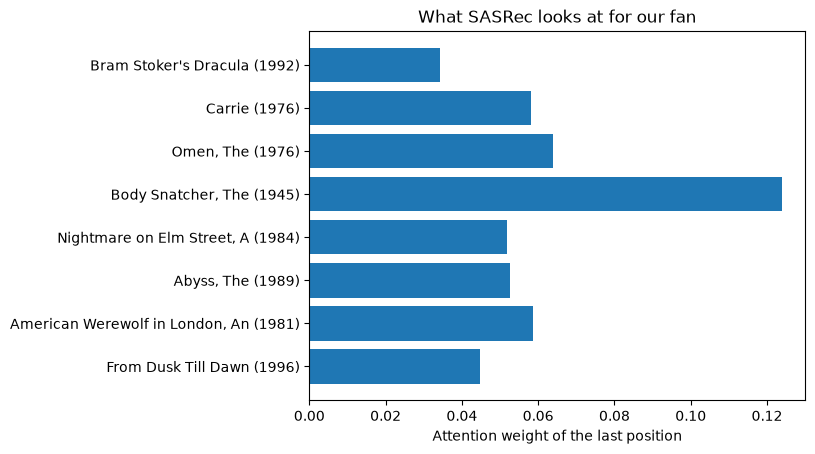

In [19]:
trail = pad(liked(fan))
with torch.no_grad():
    vectors = model.films(torch.tensor([trail])) + model.positions.weight
    _, weights = model.attention.self_attn(vectors, vectors, vectors, attn_mask=model.look_back_only)

last_films = [titles[movie] for movie in trail[-8:]]
plt.barh(last_films, weights[0, -1, -8:])
plt.xlabel("Attention weight of the last position")
plt.title("What SASRec looks at for our fan")
plt.show()

The Body Snatcher, a 1945 horror classic, gets twice the weight of the other films. And Dracula, the very last film, counts the least. Nobody told the model to do that: it learned by itself which films are the best clues.

## The superpower: order matters

Let's play with a trail. Take the last 5 films of our fan, and add three Disney films. Same 8 films, two orders: horror then Disney, and Disney then horror.

In [20]:
horror = list(liked(fan)[-5:])
disney = [titles.index(title) for title in ["Toy Story (1995)", "Aladdin (1992)", "Lion King, The (1994)"]]

def next_films(trail: list[MovieId]) -> list[str]:
    best_first = np.argsort(-next_scores(np.array(trail)), kind="stable")
    return [titles[movie] for movie in best_first if movie not in trail][:5]

print(f"Horror, then Disney: {next_films(horror + disney)}")
print(f"Disney, then horror: {next_films(disney + horror)}")

Horror, then Disney: ['E.T. the Extra-Terrestrial (1982)', 'Beauty and the Beast (1991)', 'Mary Poppins (1964)', 'Fantasia (1940)', 'Snow White and the Seven Dwarfs (1937)']
Disney, then horror: ['Shining, The (1980)', 'Robin Hood: Prince of Thieves (1991)', 'Army of Darkness (1993)', 'Birds, The (1963)', 'Natural Born Killers (1994)']


Same films, two very different lists! After the Disney films, E.T. and Beauty and the Beast. After the horror films, The Shining and Army of Darkness.

The list follows the latest taste of the user, without training again. The two towers of chapter 4 read a bag of films: both orders would give them the same list.

## In summary

| Recommender | Uses | Hit rate |
|---|---|---|
| Random | nothing | 0.034 |
| Popular | everybody's likes | 0.346 |
| 40 nearest neighbors (chapter 3) | the most similar users | 0.518 |
| Two towers, IDs only (chapter 4) | a learned vector per user and per film | 0.513 |
| Last film | what people liked right after it | 0.406 |
| Last 5 films | what people liked right after them | 0.502 |
| SASRec | the last 20 films, in order | 0.525 |

A sequential recommender reads the history as a trail, and guesses what comes next. Counting what people liked right after each film already works well, as long as we look at the last few films. SASRec goes further: its attention learns how much each earlier film counts, and it reads the order, so the list follows the user as their taste moves.

But every recommender so far looked at the likes from one side: a user and their films, or two users compared together. Yet the likes form a web: you liked a film, that someone else liked, who liked another film, that... Following these links is the idea of our next chapter: **LightGCN**.